# Etapa 4: Análisis Exploratorio (EDA) y Optimización de Inventario

Responsable: Dalma Leguizamón — Data Engineer & Machine Learning Analyst

Tarea: Análisis multidimensional de los datasets integrados para la identificación de quiebres de stock, sobrestock y cálculo de métricas críticas (ABC, Rotación y Lead Times) que fundamenten la estrategia de reabastecimiento.

## SECCIÓN I: Infraestructura y extracción

In [2]:
# Importa librerías para conexión ODBC y análisis en DataFrames.
import pyodbc
import pandas as pd

In [3]:
# Definición de parámetros de infraestructura local.
# Se utiliza un diccionario para centralizar la configuración, facilitando la 
# portabilidad entre entornos de desarrollo y producción.
config = {
    'server': 'localhost',
    'database': 'ManufacturingCompany'
}

In [4]:
# Construcción de la cadena de conexión (Connection String).
# 1. Trusted_Connection=yes: Implementa Autenticación de Windows (SSPI), 
#    eliminando la necesidad de hardcodear credenciales sensibles (UID/PWD).
# 2. Timeout=30: Define un umbral de espera crítico para evitar el bloqueo 
#    del Kernel de Python si el servidor no responde.
conn_str = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={config['server']};"
    f"DATABASE={config['database']};"
    f"Trusted_Connection=yes;"
    f"Timeout=30;"
)

In [5]:
# Abre una conexión a SQL Server usando pyodbc.
# Devuelve el objeto connection si tiene éxito; si falla, devuelve None.

def conectar_sql():
    
    try:
        conn = pyodbc.connect(conn_str)
        print("✅ Conexión establecida con éxito.")
        return conn

    except pyodbc.InterfaceError:
        print("❌ Driver ODBC no encontrado (revisar versión 17/18).")

    except pyodbc.OperationalError:
        print("❌ No se pudo conectar (servidor apagado/credenciales/puerto).")

    except Exception as e:
        print(f"❌ Error inesperado: {e}")

    return None

In [6]:
# Ejecutamos
conexion = conectar_sql()

✅ Conexión establecida con éxito.


In [7]:
# Verificamos y filtramos específicamente por el esquema 'dbo' (donde están tus tablas)
cursor = conexion.cursor()
for row in cursor.tables(schema='dbo'):
    if row.table_type == 'TABLE':
        print(f"📦 Tabla de usuario: {row.table_name}")

📦 Tabla de usuario: Brands
📦 Tabla de usuario: Inventory
📦 Tabla de usuario: Proveedor
📦 Tabla de usuario: Purchases
📦 Tabla de usuario: SalesDetail
📦 Tabla de usuario: Stores


## SECCIÓN II: Metodología de Validación (Data Quality Check)
Durante el análisis exploratorio vamos a extraer datos hacia Python/Pandas. Pandas suele inferir tipos y puede interpretar distinto (por ejemplo, DATE como object).
Por eso, primero se toma SQL Server como fuente oficial de tipado y se genera un resumen del esquema para comparar con la lectura en Pandas y luego forzar tipos si hace falta.

In [ ]:
import pandas as pd
import warnings

# Silenciamos el warning de SQLAlchemy para que no ensucie la salida
warnings.filterwarnings(
    "ignore",
    message="pandas only supports SQLAlchemy connectable*"
)

TABLAS = ["Proveedor", "Stores", "Brands", "Inventory", "Purchases", "SalesDetail"]

In [ ]:
def esquema_sql(conexion, tablas, schema="dbo"):
    filas = []  # acá vamos a ir guardando (en lista) el resultado de cada tabla

    for t in tablas:  # recorremos cada nombre de tabla en la lista "tablas"
        q = f"""
            SELECT
            '{t}' AS Tabla,                      
            c.COLUMN_NAME AS Columna,            
            c.DATA_TYPE AS Tipo_SQL,              
            c.IS_NULLABLE AS Permite_Null,        
            c.CHARACTER_MAXIMUM_LENGTH AS MaxLen,
            c.NUMERIC_PRECISION AS Precision,    
            c.NUMERIC_SCALE AS Scale,            
            c.ORDINAL_POSITION AS Posicion       
        FROM INFORMATION_SCHEMA.COLUMNS c
        WHERE c.TABLE_SCHEMA = '{schema}'        
          AND c.TABLE_NAME = '{t}'               
        ORDER BY c.ORDINAL_POSITION;                         
        """

        #   '{t}' AS Tabla,                       # agregamos el nombre de la tabla como columna fija
        #  c.COLUMN_NAME AS Columna,             # nombre de la columna
        # c.DATA_TYPE AS Tipo_SQL,              # tipo base (int, nvarchar, decimal, date, etc.)
        #    c.IS_NULLABLE AS Permite_Null,        # YES/NO si admite NULL
        #   c.CHARACTER_MAXIMUM_LENGTH AS MaxLen, # largo máximo (solo aplica a tipos texto)
        #   c.NUMERIC_PRECISION AS Precision,     # precisión (solo aplica a decimal/numeric)
        #   c.NUMERIC_SCALE AS Scale,             # escala (solo aplica a decimal/numeric)
        #   c.ORDINAL_POSITION AS Posicion        # posición de la columna en la tabla
        #FROM INFORMATION_SCHEMA.COLUMNS c
        #WHERE c.TABLE_SCHEMA = '{schema}'         # filtramos por esquema (dbo por defecto)
        #  AND c.TABLE_NAME = '{t}'                # filtramos por tabla actual
        #ORDER BY c.ORDINAL_POSITION;              # mantenemos el orden real de las columnas

        df = pd.read_sql(q, conexion)  # ejecutamos el query en SQL Server y lo traemos como DataFrame
        filas.append(df)               # guardamos este DataFrame en la lista para unirlo después

    out = pd.concat(filas, ignore_index=True)  
    # unimos todos los DataFrames (uno por tabla) en un solo DataFrame "out"
    # ignore_index=True reinicia el índice para que quede prolijo (0..n)

    def tipo_sql_completo(row):
        t = row["Tipo_SQL"]  # leemos el tipo base de SQL (ej: nvarchar, decimal, int)

        # Si el tipo es texto, en SQL se define con longitud: nvarchar(255), varchar(50), etc.
        if t in ("varchar", "nvarchar", "char", "nchar") and pd.notna(row["MaxLen"]):
            return f"{t}({int(row['MaxLen'])})"

        # Si el tipo es decimal/numeric, se define con precisión y escala: decimal(10,2)
        if t in ("decimal", "numeric") and pd.notna(row["Precision"]) and pd.notna(row["Scale"]):
            return f"{t}({int(row['Precision'])},{int(row['Scale'])})"

        return t  # si no aplica (ej: int, date), devolvemos el tipo tal cual

    out["Tipo_SQL_Completo"] = out.apply(tipo_sql_completo, axis=1)
    # creamos una nueva columna calculada con el tipo “completo” (ej: decimal(10,2))

    out = out[["Tabla", "Columna", "Tipo_SQL_Completo", "Permite_Null"]]
    # nos quedamos solo con las columnas útiles para documentación/visualización

    return out  # devolvemos el DataFrame final

sql_schema = esquema_sql(conexion, TABLAS)  # ejecutamos la función para las 6 tablas

print("\n" + "="*80)
print("ESQUEMA EN SQL SERVER (dbo) — columnas y tipos")
print("="*80)
display(sql_schema)  # mostramos el resultado en formato tabla dentro del notebook



ESQUEMA EN SQL SERVER (dbo) — columnas y tipos


,Tabla,Columna,Tipo_SQL_Completo,Permite_Null
0,Proveedor,VendorNumber,int,NO
1,Proveedor,VendorName,nvarchar(255),NO
2,Stores,StoreID,int,NO
3,Stores,StoreName,nvarchar(100),NO
4,Stores,City,nvarchar(50),YES
5,Brands,BrandID,int,NO
6,Brands,BrandDescription,nvarchar(200),NO
7,Brands,Size,nvarchar(20),YES
8,Brands,Volume,int,YES
9,Brands,Classification,int,YES


In [21]:
def esquema_pandas(conexion, tablas, schema="dbo", sample_rows=200):
    filas = []
    for t in tablas:
        q = f"SELECT TOP ({sample_rows}) * FROM {schema}.{t};"
        df = pd.read_sql(q, conexion)  # trae pocas filas (no revienta memoria)

        tmp = pd.DataFrame({
            "Tabla": t,
            "Columna": df.columns,
            "Tipo_Pandas": [str(x) for x in df.dtypes]
        })
        filas.append(tmp)

    out = pd.concat(filas, ignore_index=True)
    return out

pandas_schema = esquema_pandas(conexion, TABLAS, sample_rows=200)
print("\n" + "="*80)
print("ESQUEMA EN PANDAS — cómo quedan los dtypes al traer una muestra")
print("="*80)
display(pandas_schema)




ESQUEMA EN PANDAS — cómo quedan los dtypes al traer una muestra


,Tabla,Columna,Tipo_Pandas
0,Proveedor,VendorNumber,int64
1,Proveedor,VendorName,object
2,Stores,StoreID,int64
3,Stores,StoreName,object
4,Stores,City,object
5,Brands,BrandID,int64
6,Brands,BrandDescription,object
7,Brands,Size,object
8,Brands,Volume,int64
9,Brands,Classification,int64


In [22]:
# =========================
# 3) COMPARACIÓN SQL vs PANDAS (merge)
# =========================
comparacion = sql_schema.merge(
    pandas_schema,
    on=["Tabla", "Columna"],
    how="left"
)

print("\n" + "="*80)
print("COMPARACIÓN — SQL vs Pandas (en una sola vista)")
print("="*80)
display(comparacion)


COMPARACIÓN — SQL vs Pandas (en una sola vista)


,Tabla,Posicion,Columna,Tipo_SQL_Completo,Permite_Null,Tipo_Pandas
0,Proveedor,1,VendorNumber,int,NO,int64
1,Proveedor,2,VendorName,nvarchar(255),NO,object
2,Stores,1,StoreID,int,NO,int64
3,Stores,2,StoreName,nvarchar(100),NO,object
4,Stores,3,City,nvarchar(50),YES,object
5,Brands,1,BrandID,int,NO,int64
6,Brands,2,BrandDescription,nvarchar(200),NO,object
7,Brands,3,Size,nvarchar(20),YES,object
8,Brands,4,Volume,int,YES,int64
9,Brands,5,Classification,int,YES,int64


In [ ]:
def tipos(tabla, conexion):
    """
    Trae una tabla desde SQL Server y ajusta los tipos de datos
    en pandas según el esquema real definido en SQL.
    """

    # Traemos los datos completos de la tabla
    query_datos = f"SELECT * FROM {tabla}"
    df = pd.read_sql(query_datos, conexion)

    # Consultamos el esquema real de la tabla en SQL
    query_schema = f"""
    SELECT COLUMN_NAME, DATA_TYPE
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = '{tabla}'
    """
    esquema = pd.read_sql(query_schema, conexion)

    # Recorremos cada columna y ajustamos el tipo en pandas
    for _, fila in esquema.iterrows():
        columna = fila["COLUMN_NAME"]
        tipo_sql = fila["DATA_TYPE"]

        if columna in df.columns:

            # Enteros
            if tipo_sql in ["int", "bigint", "smallint", "tinyint"]:
                df[columna] = df[columna].astype("Int64")

            # Decimales
            elif tipo_sql in ["decimal", "numeric", "float", "real"]:
                df[columna] = df[columna].astype("float64")

            # Fechas
            elif tipo_sql in ["date", "datetime", "datetime2"]:
                df[columna] = pd.to_datetime(df[columna], errors="coerce")

            # Texto
            elif tipo_sql in ["varchar", "nvarchar", "char", "nchar", "text"]:
                df[columna] = df[columna].astype("string")

    # Devolvemos el DataFrame ya corregido
    return df



In [31]:
# Llamamos a tu función
df_test = tipos("Inventory", conexion)

# 1. Ver los primeros datos
print("Visualización de datos:")
display(df_test.head())

# 2. Verificar que los tipos coincidan con tu lógica
print("\nVerificación de tipos forzados:")
print(df_test.dtypes)

Visualización de datos:


,InventoryID,StoreID,BrandID,OnHandBegin,OnHandEnd,StartDate,EndDate
0,1_HARDERSFIELD_1000,1,1000,0,<NA>,2016-01-01,NaT
1,1_HARDERSFIELD_1001,1,1001,0,0,2016-01-01,2016-12-31
2,1_HARDERSFIELD_10021,1,10021,25,23,2016-01-01,2016-12-31
3,1_HARDERSFIELD_1003,1,1003,<NA>,0,NaT,2016-12-31
4,1_HARDERSFIELD_1004,1,1004,17,<NA>,2016-01-01,NaT



Verificación de tipos forzados:
InventoryID    string[python]
StoreID                 Int64
BrandID                 Int64
OnHandBegin             Int64
OnHandEnd               Int64
StartDate      datetime64[ns]
EndDate        datetime64[ns]
dtype: object


# Resolución Técnica: Cambio de Fuente de Datos
Tras la validación estructural realizada en la etapa anterior, se detectó que la base de datos alojada en el motor SQL Server presenta inconsistencias críticas de integridad (registros vacíos y pérdida de datos en columnas clave) que figuran en la fuente original.

Justificación del Fallback a CSV
Para garantizar un Análisis Exploratorio (EDA) basado en información 100% veraz y no comprometer la fecha estimada de entrega del proyecto académico, se ha tomado la siguiente resolución:

Acción: Se desestima el uso del motor SQL para esta fase y se procede con los archivos CSV originales.

Objetivo: Optimizar el tiempo de desarrollo eliminando la necesidad de un saneamiento manual (Data Cleaning) en SQL.

Garantía: Asegurar que los cálculos de Rotación, KPIs de Inventario y Clasificación ABC reflejen con exactitud la realidad operativa del caso de estudio.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#carga de los seis archivos csv
Precios_compras_2017=pd.read_csv("2017PurchasePricesDec.csv")
Inicio_inventario=pd.read_csv("BegInvFINAL12312016.csv") 
Final_inventario=pd.read_csv("EndInvFINAL12312016.csv")
Facturas_compras=pd.read_csv("InvoicePurchases12312016.csv")
Compra_final=pd.read_csv("PurchasesFINAL12312016.csv")
Venta_final=pd.read_csv("SalesFINAL12312016.csv")

In [4]:
Inicio_inventario['startDate'] = pd.to_datetime(Inicio_inventario['startDate'])
Final_inventario['endDate'] = pd.to_datetime(Final_inventario['endDate'])
Venta_final["SalesDate"] = pd.to_datetime(Venta_final["SalesDate"])

# Se creó una lista con los nombres de las columnas a convertir
Fechas_facturas_compras = ['InvoiceDate', 'PODate', 'PayDate'] 
Fechas_compras_final = ["PODate", "ReceivingDate", "InvoiceDate","PayDate"]

# Se aplicó la conversión a esas columnas específicas
Facturas_compras[Fechas_facturas_compras] = Facturas_compras[Fechas_facturas_compras].apply(pd.to_datetime)
Compra_final[Fechas_compras_final] = Compra_final[Fechas_compras_final].apply(pd.to_datetime)

In [5]:
Precios_compras_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12261 entries, 0 to 12260
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           12261 non-null  int64  
 1   Description     12260 non-null  object 
 2   Price           12261 non-null  float64
 3   Size            12260 non-null  object 
 4   Volume          12260 non-null  object 
 5   Classification  12261 non-null  int64  
 6   PurchasePrice   12261 non-null  float64
 7   VendorNumber    12261 non-null  int64  
 8   VendorName      12261 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 862.2+ KB


In [6]:
Inicio_inventario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206529 entries, 0 to 206528
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InventoryId  206529 non-null  object        
 1   Store        206529 non-null  int64         
 2   City         206529 non-null  object        
 3   Brand        206529 non-null  int64         
 4   Description  206529 non-null  object        
 5   Size         206529 non-null  object        
 6   onHand       206529 non-null  int64         
 7   Price        206529 non-null  float64       
 8   startDate    206529 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 14.2+ MB


In [7]:
Final_inventario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224489 entries, 0 to 224488
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InventoryId  224489 non-null  object        
 1   Store        224489 non-null  int64         
 2   City         223205 non-null  object        
 3   Brand        224489 non-null  int64         
 4   Description  224489 non-null  object        
 5   Size         224489 non-null  object        
 6   onHand       224489 non-null  int64         
 7   Price        224489 non-null  float64       
 8   endDate      224489 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 15.4+ MB


In [8]:
Facturas_compras.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   VendorNumber  5543 non-null   int64         
 1   VendorName    5543 non-null   object        
 2   InvoiceDate   5543 non-null   datetime64[ns]
 3   PONumber      5543 non-null   int64         
 4   PODate        5543 non-null   datetime64[ns]
 5   PayDate       5543 non-null   datetime64[ns]
 6   Quantity      5543 non-null   int64         
 7   Dollars       5543 non-null   float64       
 8   Freight       5543 non-null   float64       
 9   Approval      374 non-null    object        
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 433.2+ KB


In [9]:
Compra_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372474 entries, 0 to 2372473
Data columns (total 16 columns):
 #   Column          Dtype         
---  ------          -----         
 0   InventoryId     object        
 1   Store           int64         
 2   Brand           int64         
 3   Description     object        
 4   Size            object        
 5   VendorNumber    int64         
 6   VendorName      object        
 7   PONumber        int64         
 8   PODate          datetime64[ns]
 9   ReceivingDate   datetime64[ns]
 10  InvoiceDate     datetime64[ns]
 11  PayDate         datetime64[ns]
 12  PurchasePrice   float64       
 13  Quantity        int64         
 14  Dollars         float64       
 15  Classification  int64         
dtypes: datetime64[ns](4), float64(2), int64(6), object(4)
memory usage: 289.6+ MB


In [10]:
Venta_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 14 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   InventoryId     1048575 non-null  object        
 1   Store           1048575 non-null  int64         
 2   Brand           1048575 non-null  int64         
 3   Description     1048575 non-null  object        
 4   Size            1048575 non-null  object        
 5   SalesQuantity   1048575 non-null  int64         
 6   SalesDollars    1048575 non-null  float64       
 7   SalesPrice      1048575 non-null  float64       
 8   SalesDate       1048575 non-null  datetime64[ns]
 9   Volume          1048575 non-null  int64         
 10  Classification  1048575 non-null  int64         
 11  ExciseTax       1048575 non-null  float64       
 12  VendorNo        1048575 non-null  int64         
 13  VendorName      1048575 non-null  object        
dtypes: datetime64[ns](

## BLOQUE 1 – Comprensión General del Negocio
Objetivo: entender dimensión y contexto antes de analizar.

In [11]:
# Número total de productos únicos en inventario final
total_productos_final = Final_inventario["Brand"].nunique()

print("Número total de productos (Inventario Final):", total_productos_final)

Número total de productos (Inventario Final): 9653


In [12]:
# # Número total de productos
Precios_compras_2017["Brand"] = pd.to_numeric(Precios_compras_2017["Brand"], errors="coerce")
print("Número total de productos:", Precios_compras_2017["Brand"].nunique(dropna=True))
Venta_final["Store"] = pd.to_numeric(Venta_final["Store"], errors="coerce")
print("Número de sucursales:", Venta_final["Store"].nunique(dropna=True))

Número total de productos: 12261
Número de sucursales: 79


In [13]:
# Calcular extremos globales (ignorando NaT)
fechas_min = [
    Inicio_inventario["startDate"].min(),
    Final_inventario["endDate"].min(),
    Facturas_compras["InvoiceDate"].min(),
    Compra_final["ReceivingDate"].min(),
    Venta_final["SalesDate"].min()
]

fechas_max = [
    Inicio_inventario["startDate"].max(),
    Final_inventario["endDate"].max(),
    Facturas_compras["InvoiceDate"].max(),
    Compra_final["ReceivingDate"].max(),
    Venta_final["SalesDate"].max()
]

fecha_inicio = pd.Series(fechas_min).dropna().min()
fecha_fin    = pd.Series(fechas_max).dropna().max()

duracion = fecha_fin - fecha_inicio

print("PERÍODO TOTAL CUBIERTO POR EL DATASET")
print(f"🔹 Inicio: {fecha_inicio.date()}")
print(f"🔹 Fin:    {fecha_fin.date()}")
print(f"🔹 Duración total: {duracion.days} días")

PERÍODO TOTAL CUBIERTO POR EL DATASET
🔹 Inicio: 2016-01-01
🔹 Fin:    2017-01-10
🔹 Duración total: 375 días


In [14]:
# Cálculo de volumen total
total_unidades = Venta_final["SalesQuantity"].sum()
total_facturacion = Venta_final["SalesDollars"].sum()

print("Volumen total vendido (unidades): {:,.0f}".format(total_unidades))
print("Volumen total vendido (USD): ${:,.2f}".format(total_facturacion))

Volumen total vendido (unidades): 2,451,169
Volumen total vendido (USD): $33,139,375.29


In [15]:
# Cálculo de inventario total
inventario_total = Final_inventario["onHand"].sum()

print("Volumen total de inventario (unidades): {:,.0f}".format(inventario_total))

Volumen total de inventario (unidades): 4,885,776


In [16]:
# Precio representativo por producto (mediana histórica)
precio_por_brand = (
    Precios_compras_2017
    .groupby("Brand")["PurchasePrice"]
    .median()
)

# Mapear costo al inventario actual
Final_inventario["CostoUnitario"] = Final_inventario["Brand"].map(precio_por_brand)

# Valorización total
valor_total_inventario = (
    Final_inventario["onHand"] * Final_inventario["CostoUnitario"]
).sum()

print("Valor total de inventario actual (USD): {:,.2f}".format(valor_total_inventario))


Valor total de inventario actual (USD): 55,429,569.00


## BLOQUE 2 – Demanda Implícita por Variación de Inventario
Objetivo:
Estimar el comportamiento de ventas utilizando la variación anual del inventario.



In [17]:
#Stock inicial por Producto x Sucursal (resumen)
stock_ini = (
    Inicio_inventario
    .groupby(["Store","Brand"], as_index=False)["onHand"]
    .sum()
    .rename(columns={"onHand":"StockInicial"})
)
stock_ini.head()


,Store,Brand,StockInicial
0,1,58,8
1,1,60,7
2,1,62,6
3,1,63,3
4,1,72,6


In [18]:
# Compras del año por Producto x Sucursal (resumen)
compras = (
    Compra_final
    .groupby(["Store","Brand"], as_index=False)["Quantity"]
    .sum()
    .rename(columns={"Quantity":"Compras"})
)
compras.head()


,Store,Brand,Compras
0,1,58,105
1,1,60,36
2,1,62,116
3,1,63,59
4,1,77,132


In [19]:
# Stock final por Producto x Sucursal (resumen)
stock_fin = (
    Final_inventario
    .groupby(["Store","Brand"], as_index=False)["onHand"]
    .sum()
    .rename(columns={"onHand":"StockFinal"})
)
stock_fin.head()


,Store,Brand,StockFinal
0,1,58,11
1,1,62,7
2,1,63,7
3,1,72,4
4,1,75,7


In [20]:
# Unir todo en 1 sola tabla (la “tabla balance”)
balance = (
    stock_ini
    .merge(compras, on=["Store","Brand"], how="outer")
    .merge(stock_fin, on=["Store","Brand"], how="outer")
)

# Si falta alguno, se asume 0 (no hubo stock/compras/stock final)
balance[["StockInicial","Compras","StockFinal"]] = balance[["StockInicial","Compras","StockFinal"]].fillna(0)

balance.head()


,Store,Brand,StockInicial,Compras,StockFinal
0,1,58,8.0,105.0,11.0
1,1,60,7.0,36.0,0.0
2,1,62,6.0,116.0,7.0
3,1,63,3.0,59.0,7.0
4,1,72,6.0,0.0,4.0


In [21]:
# Calcular Consumo Implícito
balance["Consumo"] = balance["StockInicial"] + balance["Compras"] - balance["StockFinal"]
balance["Brand"].nunique()

11503

In [22]:
# Control de calidad básico (consumo negativo / cero / positivo)
negativos = (balance["Consumo"] < 0).sum()
ceros     = (balance["Consumo"] == 0).sum()
positivos = (balance["Consumo"] > 0).sum()

print("Resumen de Consumo:")
print("Consumo > 0 :", positivos)
print("Consumo = 0 :", ceros)
print("Consumo < 0 :", negativos)


Resumen de Consumo:
Consumo > 0 : 265958
Consumo = 0 : 8691
Consumo < 0 : 0


In [23]:
# Resumen GLOBAL por producto (empresa completa)
consumo_por_producto = (
    balance
    .groupby("Brand", as_index=False)["Consumo"]
    .sum()
    .sort_values("Consumo", ascending=False)
)

consumo_por_producto.head(10)


,Brand,Consumo
3378,8111,334939.0
844,1892,253371.0
2568,5111,241963.0
1873,3606,225741.0
3068,6570,214238.0
2273,4261,200412.0
3355,8068,187140.0
2041,3837,162879.0
1751,3405,160247.0
1571,3102,148265.0


In [24]:
# Top 20 y Bottom 20
top_20 = consumo_por_producto.head(20)
bottom_20 = consumo_por_producto.tail(20)

print("TOP 20 productos por Consumo:")
display(top_20)

print("BOTTOM 20 productos por Consumo:")
display(bottom_20)


TOP 20 productos por Consumo:


,Brand,Consumo
3378,8111,334939.0
844,1892,253371.0
2568,5111,241963.0
1873,3606,225741.0
3068,6570,214238.0
2273,4261,200412.0
3355,8068,187140.0
2041,3837,162879.0
1751,3405,160247.0
1571,3102,148265.0


BOTTOM 20 productos por Consumo:


,Brand,Consumo
6221,19980,0.0
6011,19548,0.0
6981,21856,0.0
10579,38701,0.0
5926,19313,0.0
7731,23568,0.0
11178,44339,0.0
9557,27275,0.0
3704,8979,0.0
9538,27206,0.0


In [25]:
# Top por sucursal (sin explotar el notebook)
top_por_sucursal = (
    balance[balance["Consumo"] > 0]
    .sort_values(["Store","Consumo"], ascending=[True,False])
    .groupby("Store")
    .head(10)
)

top_por_sucursal.head(30)


,Store,Brand,StockInicial,Compras,StockFinal,Consumo
2067,1,8111,58.0,6522.0,417.0,6163.0
376,1,1892,92.0,5318.0,496.0,4914.0
1047,1,3609,21.0,4960.0,378.0,4603.0
1174,1,3837,229.0,4228.0,169.0,4288.0
1290,1,4157,85.0,4414.0,305.0,4194.0
1044,1,3606,52.0,4357.0,220.0,4189.0
1282,1,4135,122.0,4056.0,356.0,3822.0
1871,1,6570,0.0,3630.0,304.0,3326.0
911,1,3315,0.0,3544.0,391.0,3153.0
2291,1,8910,95.0,3139.0,187.0,3047.0


## BLOQUE 3 – Clasificación ABC
Objetivo: priorizar gestión según impacto económico.


In [26]:
# Unir consumo con precio representativo
abc = consumo_por_producto.merge(
    precio_por_brand,
    on="Brand",
    how="left"
)

# Renombrar para claridad
abc = abc.rename(columns={"PurchasePrice": "PrecioRepresentativo"})

# Calcular revenue implícito
abc["RevenueImplicito"] = abc["Consumo"] * abc["PrecioRepresentativo"]

# Eliminar posibles NaN
abc = abc.dropna(subset=["RevenueImplicito"])

abc.head()


,Brand,Consumo,PrecioRepresentativo,RevenueImplicito
0,8111,334939.0,0.77,257903.03
1,1892,253371.0,0.72,182427.12
2,5111,241963.0,0.72,174213.36
3,3606,225741.0,0.74,167048.34
4,6570,214238.0,6.77,1450391.26


In [27]:
# Ordenar por impacto económico
abc = abc.sort_values("RevenueImplicito", ascending=False).reset_index(drop=True)
abc.head()

,Brand,Consumo,PrecioRepresentativo,RevenueImplicito
0,1233,142049.0,26.27,3731627.23
1,3405,160247.0,23.19,3716127.93
2,8068,187140.0,18.24,3413433.60
3,4261,200412.0,16.17,3240662.04
4,3545,135838.0,21.89,2973493.82


In [28]:
# Total revenue
total_revenue = abc["RevenueImplicito"].sum()

# % individual
abc["Pct_Individual"] = abc["RevenueImplicito"] / total_revenue

# % acumulado
abc["Pct_Acumulado"] = abc["Pct_Individual"].cumsum()

abc[["RevenueImplicito","Pct_Individual","Pct_Acumulado"]].head(15)




,RevenueImplicito,Pct_Individual,Pct_Acumulado
0,3731627.23,0.011907,0.011907
1,3716127.93,0.011858,0.023765
2,3413433.60,0.010892,0.034658
3,3240662.04,0.010341,0.044998
4,2973493.82,0.009488,0.054487
5,2520852.20,0.008044,0.062531
6,2141726.52,0.006834,0.069365
7,1918549.10,0.006122,0.075487
8,1875671.13,0.005985,0.081472
9,1744023.69,0.005565,0.087037


In [29]:
def clasificacion_abc(pct_acum):
    if pct_acum <= 0.80:
        return "A"
    elif pct_acum <= 0.95:
        return "B"
    else:
        return "C"

abc["CategoriaABC"] = abc["Pct_Acumulado"].apply(clasificacion_abc)

abc[["RevenueImplicito","Pct_Acumulado","CategoriaABC"]].head(20)


,RevenueImplicito,Pct_Acumulado,CategoriaABC
0,3731627.23,0.011907,A
1,3716127.93,0.023765,A
2,3413433.60,0.034658,A
3,3240662.04,0.044998,A
4,2973493.82,0.054487,A
5,2520852.20,0.062531,A
6,2141726.52,0.069365,A
7,1918549.10,0.075487,A
8,1875671.13,0.081472,A
9,1744023.69,0.087037,A


In [30]:
total_revenue = abc["RevenueImplicito"].sum()

resumen = (abc.groupby("CategoriaABC")
           .agg(Productos=("Brand","count"),
                Revenue_USD=("RevenueImplicito","sum"),
                Consumo_Total=("Consumo","sum"))
           .assign(Pct_Revenue=lambda d: d["Revenue_USD"] / total_revenue)
           .sort_index())

# Formato lindo (solo para mostrar)
resumen_style = resumen.style.format({
    "Revenue_USD": "${:,.2f}",
    "Pct_Revenue": "{:.2%}",
    "Consumo_Total": "{:,.0f}"
})

resumen_style


,Productos,Revenue_USD,Consumo_Total,Pct_Revenue
CategoriaABC,,,,
A,1550,"$250,674,054.60","24,520,145",79.99%
B,2097,"$47,041,200.60","6,470,548",15.01%
C,7856,"$15,670,044.74","1,927,183",5.00%


In [31]:
print("Total productos:", len(abc))
print("Total revenue implícito: ${:,.2f}".format(total_revenue))


Total productos: 11503
Total revenue implícito: $313,385,299.94


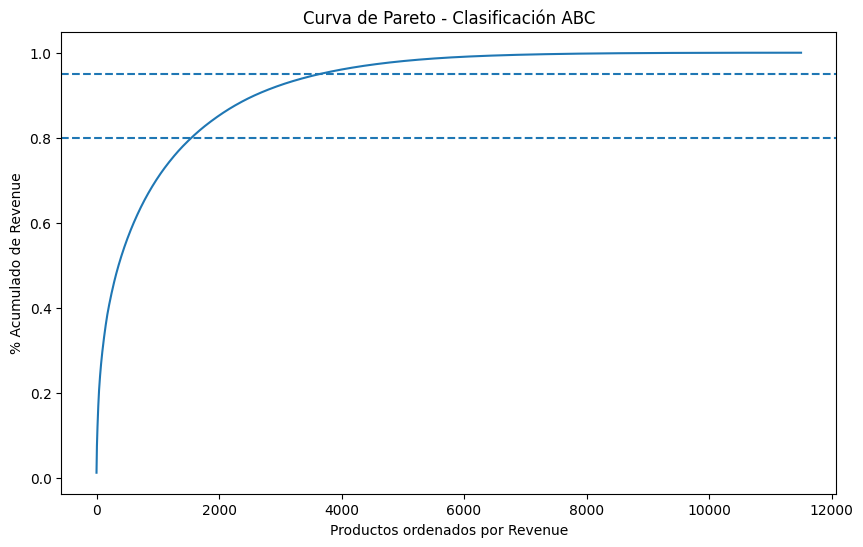

In [32]:
plt.figure(figsize=(10,6))
plt.plot(abc["Pct_Acumulado"].values)
plt.axhline(0.80, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.title("Curva de Pareto - Clasificación ABC")
plt.xlabel("Productos ordenados por Revenue")
plt.ylabel("% Acumulado de Revenue")
plt.show()



## BLOQUE 4 – Análisis de Rotación
Objetivo: medir la eficiencia del inventario.



In [33]:
# Definir parámetros operativos del análisis
MIN_INV_PROM = 5
CAP_PERCENTIL = 0.99
MAX_ROT_PLOT = None 

In [34]:
# Consolidar por producto: stock inicial, stock final y consumo total
rotacion = (
    balance
    .groupby("Brand", as_index=False)
    .agg(
        StockInicial=("StockInicial", "sum"),
        StockFinal=("StockFinal", "sum"),
        Consumo=("Consumo", "sum")
    )
)
rotacion.head()

,Brand,StockInicial,StockFinal,Consumo
0,58,281.0,385.0,3446.0
1,60,288.0,146.0,1775.0
2,61,12.0,12.0,312.0
3,62,384.0,459.0,3125.0
4,63,365.0,442.0,2778.0


In [35]:
# Calcular inventario promedio anual
rotacion["InventarioPromedio"] = (
    rotacion["StockInicial"] + rotacion["StockFinal"]) / 2

rotacion[["Brand","InventarioPromedio"]].head()

,Brand,InventarioPromedio
0,58,333.0
1,60,217.0
2,61,12.0
3,62,421.5
4,63,403.5


In [36]:
# Marcar productos donde rotación es interpretable (evita explosiones por denominador chico)
rotacion["Evaluable"] = (
    rotacion["InventarioPromedio"] >= MIN_INV_PROM) & (rotacion["Consumo"] > 0)

rotacion.head()

,Brand,StockInicial,StockFinal,Consumo,InventarioPromedio,Evaluable
0,58,281.0,385.0,3446.0,333.0,True
1,60,288.0,146.0,1775.0,217.0,True
2,61,12.0,12.0,312.0,12.0,True
3,62,384.0,459.0,3125.0,421.5,True
4,63,365.0,442.0,2778.0,403.5,True


In [37]:
# Calcular rotación anual solo para productos evaluables y redondear a entero
rotacion["Rotacion"] = np.where(
    rotacion["Evaluable"],
    (rotacion["Consumo"] / rotacion["InventarioPromedio"]).round(0),
    np.nan
)

# Convertir a entero (sin decimales visibles)
rotacion["Rotacion"] = rotacion["Rotacion"].astype("Int64")

rotacion.head()

,Brand,StockInicial,StockFinal,Consumo,InventarioPromedio,Evaluable,Rotacion
0,58,281.0,385.0,3446.0,333.0,True,10
1,60,288.0,146.0,1775.0,217.0,True,8
2,61,12.0,12.0,312.0,12.0,True,26
3,62,384.0,459.0,3125.0,421.5,True,7
4,63,365.0,442.0,2778.0,403.5,True,7


In [38]:
# Calcular días promedio en inventario solo si rotación es válida
rotacion["DiasInventario"] = np.where(
    rotacion["Rotacion"].notna() & (rotacion["Rotacion"] > 0),
    365 / rotacion["Rotacion"],
    np.nan
)

# Limpiar infinitos antes de convertir
rotacion.replace([np.inf, -np.inf], np.nan, inplace=True)

# Redondear antes de convertir
rotacion["Rotacion"] = rotacion["Rotacion"].round(0)
rotacion["DiasInventario"] = rotacion["DiasInventario"].round(0)

# Convertir a enteros (manteniendo NaN permitidos)
rotacion["Rotacion"] = rotacion["Rotacion"].astype("Int64")
rotacion["DiasInventario"] = rotacion["DiasInventario"].astype("Int64")

rotacion.head()


,Brand,StockInicial,StockFinal,Consumo,InventarioPromedio,Evaluable,Rotacion,DiasInventario
0,58,281.0,385.0,3446.0,333.0,True,10,36
1,60,288.0,146.0,1775.0,217.0,True,8,46
2,61,12.0,12.0,312.0,12.0,True,26,14
3,62,384.0,459.0,3125.0,421.5,True,7,52
4,63,365.0,442.0,2778.0,403.5,True,7,52


In [39]:
# Incorporar categoría ABC para comparaciones
if "abc" in globals() and {"Brand", "CategoriaABC"}.issubset(set(abc.columns)):
    rotacion = rotacion.merge(abc[["Brand", "CategoriaABC"]], on="Brand", how="left")
else:
    rotacion["CategoriaABC"] = "SinABC"

rotacion.head()

,Brand,StockInicial,StockFinal,Consumo,InventarioPromedio,Evaluable,Rotacion,DiasInventario,CategoriaABC
0,58,281.0,385.0,3446.0,333.0,True,10,36,B
1,60,288.0,146.0,1775.0,217.0,True,8,46,B
2,61,12.0,12.0,312.0,12.0,True,26,14,C
3,62,384.0,459.0,3125.0,421.5,True,7,52,A
4,63,365.0,442.0,2778.0,403.5,True,7,52,A


In [40]:
# Reportar cuántos productos quedaron fuera por criterio de evaluabilidad
total = len(rotacion)
no_eval = (~rotacion["Evaluable"]).sum()
pct_no_eval = round(no_eval / total * 100, 2)

print(f"Total Brands: {total}")
print(f"No evaluables (inv promedio < {MIN_INV_PROM} o consumo=0): {no_eval} ({pct_no_eval}%)")

Total Brands: 11503
No evaluables (inv promedio < 5 o consumo=0): 2049 (17.81%)


In [41]:
# Crear dataset evaluable (donde rotación y días tienen sentido)
rot_eval = rotacion[rotacion["Evaluable"]].copy()

In [42]:
# Aplicar cap percentil para que los gráficos no queden aplastados por outliers
if len(rot_eval) > 0:
    cap_rot = rot_eval["Rotacion"].quantile(CAP_PERCENTIL)
    cap_days = rot_eval["DiasInventario"].quantile(CAP_PERCENTIL)

    rot_eval["Rotacion_plot"] = rot_eval["Rotacion"].clip(upper=cap_rot)
    rot_eval["DiasInventario_plot"] = rot_eval["DiasInventario"].clip(upper=cap_days)

    if MAX_ROT_PLOT is not None:
        rot_eval["Rotacion_plot"] = rot_eval["Rotacion_plot"].clip(upper=MAX_ROT_PLOT)

    print(f"Cap Rotación (p{int(CAP_PERCENTIL*100)}): {round(cap_rot,2)}")
    print(f"Cap Días (p{int(CAP_PERCENTIL*100)}): {round(cap_days,1)}")
else:
    print("No hay filas evaluables. Probá bajar MIN_INV_PROM.")

Cap Rotación (p99): 47.0
Cap Días (p99): 365


In [43]:
# Resumir rotación y días por categoría ABC (solo evaluables)
resumen_rot = (
    rot_eval
    .groupby("CategoriaABC", as_index=False)
    .agg(
        Productos=("Brand", "count"),
        Rotacion_Promedio=("Rotacion", "mean"),
        Rotacion_Mediana=("Rotacion", "median"),
        Dias_Promedio=("DiasInventario", "mean"),
        Dias_Mediana=("DiasInventario", "median"),
    )
)

resumen_rot["Rotacion_Promedio"] = resumen_rot["Rotacion_Promedio"].round(2)
resumen_rot["Rotacion_Mediana"]  = resumen_rot["Rotacion_Mediana"].round(2)
resumen_rot["Dias_Promedio"]     = resumen_rot["Dias_Promedio"].round(1)
resumen_rot["Dias_Mediana"]      = resumen_rot["Dias_Mediana"].round(1)

resumen_rot

,CategoriaABC,Productos,Rotacion_Promedio,Rotacion_Mediana,Dias_Promedio,Dias_Mediana
0,A,1541,12.42,7.0,58.6,52.0
1,B,2047,10.87,5.0,87.7,73.0
2,C,5866,4.04,2.0,175.1,182.0


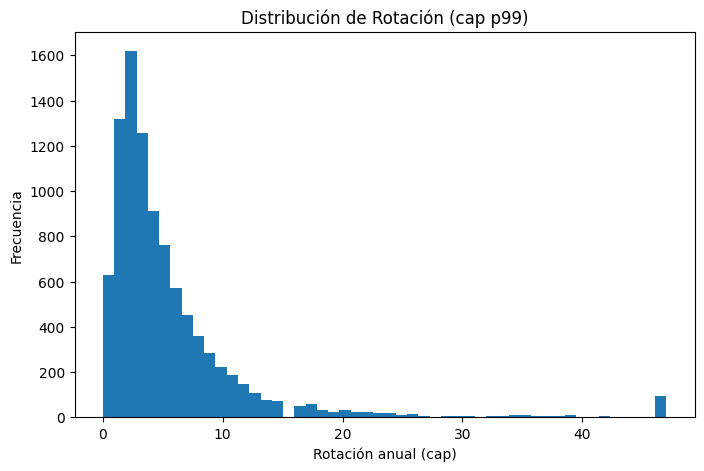

In [44]:
# Visualizar la distribución de rotación evitando outliers extremos
plt.figure(figsize=(8,5))
plt.hist(rot_eval["Rotacion_plot"], bins=50)
plt.title("Distribución de Rotación (cap p99)")
plt.xlabel("Rotación anual (cap)")
plt.ylabel("Frecuencia")
plt.show()

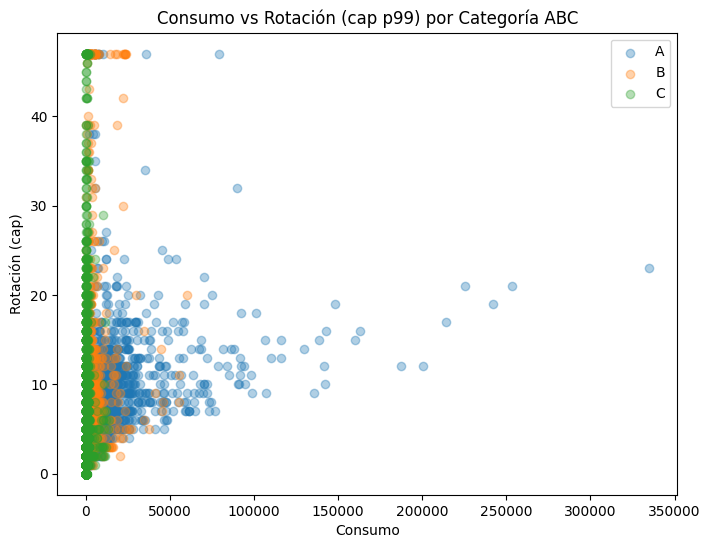

In [45]:
# Relacionar demanda (Consumo) vs eficiencia (Rotación) segmentando por ABC
plt.figure(figsize=(8,6))

cats = ["A", "B", "C"]
for cat in cats:
    sub = rot_eval[rot_eval["CategoriaABC"] == cat]
    if len(sub) > 0:
        plt.scatter(sub["Consumo"], sub["Rotacion_plot"], alpha=0.35, label=cat)

sub_na = rot_eval[~rot_eval["CategoriaABC"].isin(cats)]
if len(sub_na) > 0:
    plt.scatter(sub_na["Consumo"], sub_na["Rotacion_plot"], alpha=0.20, label="SinABC")

plt.title("Consumo vs Rotación (cap p99) por Categoría ABC")
plt.xlabel("Consumo")
plt.ylabel("Rotación (cap)")
plt.legend()
plt.show()

In [46]:
# Identificar productos extremos usando rotación real (sin cap)
top10 = (rot_eval.sort_values("Rotacion", ascending=False)
         .head(10)[["Brand","Consumo","InventarioPromedio","Rotacion","DiasInventario","CategoriaABC"]])

bottom10 = (rot_eval.sort_values("Rotacion", ascending=True)
            .head(10)[["Brand","Consumo","InventarioPromedio","Rotacion","DiasInventario","CategoriaABC"]])

print("TOP 10 Rotación (evaluables):")
display(top10)

print("BOTTOM 10 Rotación (evaluables):")
display(bottom10)

TOP 10 Rotación (evaluables):


,Brand,Consumo,InventarioPromedio,Rotacion,DiasInventario,CategoriaABC
2272,4260,79042.0,19.0,4160,0,A
8579,25202,5547.0,6.0,924,0,A
6960,21791,5560.0,7.5,741,0,B
614,1195,14677.0,22.0,667,1,B
8791,25587,3344.0,6.0,557,1,B
1675,3288,4669.0,9.5,491,1,A
559,1076,17309.0,35.5,488,1,B
1968,3737,2575.0,5.5,468,1,B
647,1261,23667.0,53.5,442,1,B
8940,25827,2647.0,6.5,407,1,B


BOTTOM 10 Rotación (evaluables):


,Brand,Consumo,InventarioPromedio,Rotacion,DiasInventario,CategoriaABC
40,150,1.0,9.5,0,<NA>,C
39,148,4.0,10.0,0,<NA>,C
8345,24776,2.0,5.0,0,<NA>,C
8342,24773,1.0,11.5,0,<NA>,C
8382,24845,59.0,132.5,0,<NA>,C
8363,24804,5.0,18.5,0,<NA>,C
8400,24881,103.0,264.5,0,<NA>,C
8399,24878,7.0,20.5,0,<NA>,C
8414,24922,60.0,190.0,0,<NA>,C
8413,24921,48.0,197.0,0,<NA>,C


## BLOQUE 5 – SALUD DEL INVENTARIO

Objetivo: detectar excesos y riesgos operativos.

In [47]:
# Parámetros generales

TOP_N = 10

# Umbrales para productos (percentiles sobre Brand)
PCT_STOCK_ALTO = 0.90
PCT_STOCK_BAJO = 0.25
PCT_CONSUMO_ALTO = 0.75
PCT_CONSUMO_BAJO = 0.25

# Corte para recategorización de tiendas 
CORTE_TIENDA = "mediana"   # "mediana" (simple) o "p75_p25" 

print(" PARÁMETROS")
print(f"TOP_N productos a mostrar: {TOP_N}")
print(f"Stock alto: p{int(PCT_STOCK_ALTO*100)} | Stock bajo: p{int(PCT_STOCK_BAJO*100)}")
print(f"Consumo alto: p{int(PCT_CONSUMO_ALTO*100)} | Consumo bajo: p{int(PCT_CONSUMO_BAJO*100)}")
print(f"Corte para tiendas (2x2): {CORTE_TIENDA}")




 PARÁMETROS
TOP_N productos a mostrar: 10
Stock alto: p90 | Stock bajo: p25
Consumo alto: p75 | Consumo bajo: p25
Corte para tiendas (2x2): mediana


In [48]:
# Centralizamos las métricas de inventario y demanda a nivel de producto, integrando la clasificación estratégica ABC para segmentar el estado operativo del stock.

inv_brand = (
    balance
    .groupby("Brand", as_index=False)
    .agg(
        StockFinal=("StockFinal", "sum"),
        Consumo=("Consumo", "sum")
    )
)

# Unir ABC
inv_brand = inv_brand.merge(abc[["Brand", "CategoriaABC"]], on="Brand", how="left")
inv_brand["CategoriaABC"] = inv_brand["CategoriaABC"].fillna("SinABC")

# Métricas útiles
inv_brand["TieneDemanda"] = inv_brand["Consumo"] > 0
inv_brand["StockCero"] = inv_brand["StockFinal"] == 0

print("Marcas totales:", len(inv_brand))
print("Marcas con demanda (Consumo>0):", int(inv_brand["TieneDemanda"].sum()))
print("Marcas con stock final = 0:", int(inv_brand["StockCero"].sum()))
print("Distribución ABC (conteo):")
print(inv_brand["CategoriaABC"].value_counts(dropna=False))

Marcas totales: 11503
Marcas con demanda (Consumo>0): 11237
Marcas con stock final = 0: 2004
Distribución ABC (conteo):
CategoriaABC
C    7856
B    2097
A    1550
Name: count, dtype: int64


In [49]:
# Identificamo productos con demanda activa pero sin inventario disponible, señalando una pérdida potencial de ventas inmediata.

quiebre = inv_brand[(inv_brand["StockCero"]) & (inv_brand["TieneDemanda"])].copy()

pct_brands_quiebre = round(len(quiebre) / len(inv_brand) * 100, 2)
consumo_total = inv_brand["Consumo"].sum()
consumo_quiebre = quiebre["Consumo"].sum()
pct_consumo_en_quiebre = round(consumo_quiebre / consumo_total * 100, 2) if consumo_total > 0 else 0

print("QUIEBRE (StockFinal=0 y Consumo>0)")
print(f"Brands en quiebre: {len(quiebre)} / {len(inv_brand)} ({pct_brands_quiebre}%)")
print(f"Consumo asociado al quiebre: {consumo_quiebre:,.0f} / {consumo_total:,.0f} ({pct_consumo_en_quiebre}%)")

print("ABC dentro del quiebre (conteo y %):")
mix_q = (quiebre["CategoriaABC"].value_counts(dropna=False).to_frame("Cantidad"))
mix_q["%"] = (mix_q["Cantidad"] / len(quiebre) * 100).round(2)
display(mix_q)

print("TOP productos en quiebre (más consumo):")
display(quiebre.sort_values("Consumo", ascending=False).head(TOP_N)[
    ["Brand","CategoriaABC","Consumo","StockFinal"]
])

QUIEBRE (StockFinal=0 y Consumo>0)
Brands en quiebre: 1939 / 11503 (16.86%)
Consumo asociado al quiebre: 370,174 / 32,917,876 (1.12%)
ABC dentro del quiebre (conteo y %):


,Cantidad,%
CategoriaABC,,
C,1866,96.24
B,66,3.40
A,7,0.36


TOP productos en quiebre (más consumo):


,Brand,CategoriaABC,Consumo,StockFinal
725,1476,A,15044.0,0.0
3587,8606,C,10465.0,0.0
8554,25163,B,10367.0,0.0
3471,8358,A,8065.0,0.0
6183,19896,A,7426.0,0.0
2693,5390,C,7007.0,0.0
8455,24995,B,5661.0,0.0
8728,25504,B,5531.0,0.0
8785,25577,A,5442.0,0.0
8122,24369,A,5322.0,0.0


In [50]:
# Detectamos productos con inventario excesivo y baja rotación mediante cuantiles, localizando el capital inmovilizado que genera ineficiencia financiera.

stock_alto = inv_brand["StockFinal"].quantile(PCT_STOCK_ALTO)
consumo_bajo = inv_brand["Consumo"].quantile(PCT_CONSUMO_BAJO)

sobrestock = inv_brand[
    (inv_brand["StockFinal"] >= stock_alto) &
    (inv_brand["Consumo"] <= consumo_bajo)
].copy()

pct_brands_sobrestock = round(len(sobrestock) / len(inv_brand) * 100, 2)
stock_total = inv_brand["StockFinal"].sum()
stock_sobrestock = sobrestock["StockFinal"].sum()
pct_stock_inmov = round(stock_sobrestock / stock_total * 100, 2) if stock_total > 0 else 0

print("SOBREESTOCK (Stock alto + Consumo bajo)")
print(f"Umbral Stock alto (%{int(PCT_STOCK_ALTO*100)}): {stock_alto:,.2f}")
print(f"Umbral Consumo bajo (%{int(PCT_CONSUMO_BAJO*100)}): {consumo_bajo:,.2f}")
print(f"Marcas en sobrestock: {len(sobrestock)} / {len(inv_brand)} ({pct_brands_sobrestock}%)")
print(f"Stock asociado al sobrestock: {stock_sobrestock:,.0f} / {stock_total:,.0f} ({pct_stock_inmov}%)")

print(" ABC dentro del sobrestock (conteo y %):")
mix_s = (sobrestock["CategoriaABC"].value_counts(dropna=False).to_frame("Cantidad"))
mix_s["%"] = (mix_s["Cantidad"] / len(sobrestock) * 100).round(2)
display(mix_s)

print("TOP productos en sobrestock (más stock):")
display(sobrestock.sort_values("StockFinal", ascending=False).head(TOP_N)[
    ["Brand","CategoriaABC","StockFinal","Consumo"]
])

SOBREESTOCK (Stock alto + Consumo bajo)
Umbral Stock alto (%90): 1,097.00
Umbral Consumo bajo (%25): 23.00
Marcas en sobrestock: 1 / 11503 (0.01%)
Stock asociado al sobrestock: 1,140 / 4,885,776 (0.02%)
 ABC dentro del sobrestock (conteo y %):


,Cantidad,%
CategoriaABC,,
C,1,100.0


TOP productos en sobrestock (más stock):


,Brand,CategoriaABC,StockFinal,Consumo
555,1071,C,1140.0,0.0


In [51]:
# Filtramos los productos de alta rotación (Top 25% de demanda) que tienen stock agotado, priorizando las rupturas de inventario que más impactan en la facturación.

consumo_alto = inv_brand["Consumo"].quantile(PCT_CONSUMO_ALTO)

riesgo_critico = inv_brand[
    (inv_brand["StockFinal"] == 0) &
    (inv_brand["Consumo"] >= consumo_alto)
].copy()

pct_brands_riesgo = round(len(riesgo_critico) / len(inv_brand) * 100, 2)
consumo_riesgo = riesgo_critico["Consumo"].sum()
pct_consumo_riesgo = round(consumo_riesgo / consumo_total * 100, 2) if consumo_total > 0 else 0

print("RIESGO CRÍTICO (Stock=0 + Consumo alto)")
print(f"Umbral Consumo alto (%{int(PCT_CONSUMO_ALTO*100)}): {consumo_alto:,.2f}")
print(f"Brands críticos: {len(riesgo_critico)} / {len(inv_brand)} ({pct_brands_riesgo}%)")
print(f"Consumo asociado a críticos: {consumo_riesgo:,.0f} / {consumo_total:,.0f} ({pct_consumo_riesgo}%)")

print("ABC dentro del riesgo crítico (conteo y %):")
mix_rc = (riesgo_critico["CategoriaABC"].value_counts(dropna=False).to_frame("Cantidad"))
mix_rc["%"] = (mix_rc["Cantidad"] / len(riesgo_critico) * 100).round(2)
display(mix_rc)

print("TOP críticos (más consumo):")
display(riesgo_critico.sort_values("Consumo", ascending=False).head(TOP_N)[
    ["Brand","CategoriaABC","Consumo","StockFinal"]
])

RIESGO CRÍTICO (Stock=0 + Consumo alto)
Umbral Consumo alto (%75): 1,643.00
Brands críticos: 52 / 11503 (0.45%)
Consumo asociado a críticos: 205,840 / 32,917,876 (0.63%)
ABC dentro del riesgo crítico (conteo y %):


,Cantidad,%
CategoriaABC,,
B,36,69.23
C,9,17.31
A,7,13.46


TOP críticos (más consumo):


,Brand,CategoriaABC,Consumo,StockFinal
725,1476,A,15044.0,0.0
3587,8606,C,10465.0,0.0
8554,25163,B,10367.0,0.0
3471,8358,A,8065.0,0.0
6183,19896,A,7426.0,0.0
2693,5390,C,7007.0,0.0
8455,24995,B,5661.0,0.0
8728,25504,B,5531.0,0.0
8785,25577,A,5442.0,0.0
8122,24369,A,5322.0,0.0


In [52]:
# Calculamo la relación entre el inventario remanente y la demanda anual por punto de venta para identificar desequilibrios en la distribución regional de mercadería.
inv_store = (
    balance
    .groupby("Store", as_index=False)
    .agg(
        StockFinal=("StockFinal","sum"),
        Consumo=("Consumo","sum")
    )
)

# Cortes (mediana o p75/p25)
if CORTE_TIENDA == "mediana":
    corte_stock = inv_store["StockFinal"].median()
    corte_consumo = inv_store["Consumo"].median()
else:
    corte_stock = inv_store["StockFinal"].quantile(0.75)
    corte_consumo = inv_store["Consumo"].quantile(0.75)

inv_store["NivelStock"] = np.where(inv_store["StockFinal"] >= corte_stock, "StockAlto", "StockBajo")
inv_store["NivelDemanda"] = np.where(inv_store["Consumo"] >= corte_consumo, "DemandaAlta", "DemandaBaja")

inv_store["TipoTienda"] = inv_store["NivelDemanda"] + " + " + inv_store["NivelStock"]

print("TIPOS DE TIENDA (4 CUADRANTES)")
print("Tiendas totales:", len(inv_store))
print(f"Corte StockFinal: {corte_stock:,.0f} | Corte Consumo: {corte_consumo:,.0f}")
print("Conteo de tiendas por tipo:")
display(inv_store["TipoTienda"].value_counts().to_frame("Tiendas"))

print("Top 10:")
display(inv_store.head(10))

TIPOS DE TIENDA (4 CUADRANTES)
Tiendas totales: 80
Corte StockFinal: 47,252 | Corte Consumo: 326,174
Conteo de tiendas por tipo:


,Tiendas
TipoTienda,
DemandaAlta + StockAlto,34
DemandaBaja + StockBajo,34
DemandaBaja + StockAlto,6
DemandaAlta + StockBajo,6


Top 10:


,Store,StockFinal,Consumo,NivelStock,NivelDemanda,TipoTienda
0,1,79827.0,558588.0,StockAlto,DemandaAlta,DemandaAlta + StockAlto
1,2,56671.0,417757.0,StockAlto,DemandaAlta,DemandaAlta + StockAlto
2,3,8470.0,35111.0,StockBajo,DemandaBaja,DemandaBaja + StockBajo
3,4,60570.0,269520.0,StockAlto,DemandaBaja,DemandaBaja + StockAlto
4,5,21708.0,124104.0,StockBajo,DemandaBaja,DemandaBaja + StockBajo
5,6,48303.0,461757.0,StockAlto,DemandaAlta,DemandaAlta + StockAlto
6,7,50780.0,409837.0,StockAlto,DemandaAlta,DemandaAlta + StockAlto
7,8,40390.0,281492.0,StockBajo,DemandaBaja,DemandaBaja + StockBajo
8,9,47401.0,465680.0,StockAlto,DemandaAlta,DemandaAlta + StockAlto
9,10,85230.0,636618.0,StockAlto,DemandaAlta,DemandaAlta + StockAlto


In [53]:
# Determina la profundidad y composición del catálogo activo en cada tipo de tienda. 
# Permite verificar si las tiendas críticas están priorizando el surtido de mayor valor (Clase A) o si su stock está diluido en productos de baja rotación (Clase C).
store_brand = (
    balance
    .groupby(["Store","Brand"], as_index=False)
    .agg(
        StockFinal=("StockFinal","sum"),
        Consumo=("Consumo","sum")
    )
)

# 2) Pegamos ABC
store_brand = store_brand.merge(abc[["Brand","CategoriaABC"]], on="Brand", how="left")
store_brand["CategoriaABC"] = store_brand["CategoriaABC"].fillna("SinABC")

# 3) Pegamos tipo de tienda
store_brand = store_brand.merge(inv_store[["Store","TipoTienda"]], on="Store", how="left")

print("ABC POR TIPO DE TIENDA")

# Conteo de brands distintos por tipo y ABC
mix_tienda = (
    store_brand[store_brand["Consumo"] > 0]  # solo productos que realmente se mueven en esa tienda
    .groupby(["TipoTienda","CategoriaABC"])["Brand"]
    .nunique()
    .reset_index(name="Brands_Unicos")
)

# % dentro de cada tipo de tienda
mix_tienda["%_en_TipoTienda"] = (
    mix_tienda.groupby("TipoTienda")["Brands_Unicos"]
    .apply(lambda s: (s / s.sum() * 100).round(2))
    .reset_index(drop=True)
)

display(mix_tienda.sort_values(["TipoTienda","CategoriaABC"]))

ABC POR TIPO DE TIENDA


,TipoTienda,CategoriaABC,Brands_Unicos,%_en_TipoTienda
0,DemandaAlta + StockAlto,A,1550,14.17
1,DemandaAlta + StockAlto,B,2096,19.16
2,DemandaAlta + StockAlto,C,7294,66.67
3,DemandaAlta + StockBajo,A,1540,31.51
4,DemandaAlta + StockBajo,B,1749,35.78
5,DemandaAlta + StockBajo,C,1599,32.71
6,DemandaBaja + StockAlto,A,1540,28.10
7,DemandaBaja + StockAlto,B,1955,35.68
8,DemandaBaja + StockAlto,C,1985,36.22
9,DemandaBaja + StockBajo,A,1540,26.23


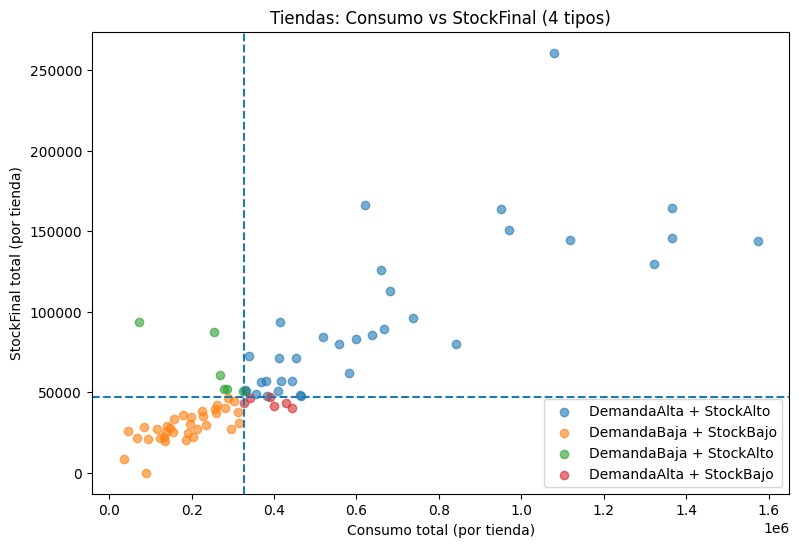

In [54]:
# Filtramos los productos del cuartil superior de demanda con inventario agotado para identificar las brechas de stock que generan la mayor pérdida de ingresos potencial.

plt.figure(figsize=(9,6))

tipos = inv_store["TipoTienda"].unique()
for t in tipos:
    sub = inv_store[inv_store["TipoTienda"] == t]
    plt.scatter(sub["Consumo"], sub["StockFinal"], alpha=0.6, label=t)

plt.axvline(corte_consumo, linestyle="--")
plt.axhline(corte_stock, linestyle="--")
plt.title("Tiendas: Consumo vs StockFinal (4 tipos)")
plt.xlabel("Consumo total (por tienda)")
plt.ylabel("StockFinal total (por tienda)")
plt.legend()
plt.show()

In [55]:
# Ratio por tipo de tienda y categoría ABC
mix_tienda = (
    store_brand
    .groupby(["TipoTienda", "CategoriaABC"], as_index=False)
    .agg(
        StockFinal=("StockFinal","sum"),
        Consumo=("Consumo","sum")
    )
)

# Ratio expresado en %
mix_tienda["Cobertura_%"] = np.where(
    mix_tienda["Consumo"] > 0,
    (mix_tienda["StockFinal"] / mix_tienda["Consumo"]) * 100,
    np.nan
).round(2)

display(mix_tienda.sort_values(["TipoTienda","CategoriaABC"]))

,TipoTienda,CategoriaABC,StockFinal,Consumo,Cobertura_%
0,DemandaAlta + StockAlto,A,1823089.0,16311728.0,11.18
1,DemandaAlta + StockAlto,B,855614.0,4919958.0,17.39
2,DemandaAlta + StockAlto,C,568615.0,1571853.0,36.17
3,DemandaAlta + StockBajo,A,172485.0,1871143.0,9.22
4,DemandaAlta + StockBajo,B,62926.0,381037.0,16.51
5,DemandaAlta + StockBajo,C,26276.0,81817.0,32.12
6,DemandaBaja + StockAlto,A,254214.0,1141505.0,22.27
7,DemandaBaja + StockAlto,B,103398.0,278938.0,37.07
8,DemandaBaja + StockAlto,C,38662.0,65589.0,58.95
9,DemandaBaja + StockBajo,A,717803.0,5195769.0,13.82


 ## BLOQUE 6 – Análisis de Lead Time
 Objetivo: entender abastecimiento.

In [56]:
proveedores_unicos = Compra_final["VendorNumber"].nunique()
print("Cantidad de proveedores únicos:", proveedores_unicos)

Cantidad de proveedores únicos: 126


In [57]:
# Promedio de lead time por proveedor

Compra_final["LeadTimeDays"] = (Compra_final["ReceivingDate"] - Compra_final["PODate"]).dt.days

# Promedio de lead time por proveedor
vendor_lt = (
    Compra_final
    .groupby("VendorNumber")["LeadTimeDays"]
    .mean()
    .reset_index(name="LT_Promedio")
)

print("Cantidad de proveedores analizados:", vendor_lt["VendorNumber"].nunique())

print("\nEstadísticas Lead Time (días):")
print(vendor_lt["LT_Promedio"].describe(percentiles=[0.25, 0.50, 0.75, 0.90]).to_string())

print("\nLead Time mínimo proveedor:", vendor_lt["LT_Promedio"].min())
print("Lead Time máximo proveedor:", vendor_lt["LT_Promedio"].max())

Cantidad de proveedores analizados: 126

Estadísticas Lead Time (días):
count    126.000000
mean       7.748599
std        0.780303
min        5.000000
25%        7.470760
50%        7.666354
75%        7.949221
90%        8.278595
max       13.000000

Lead Time mínimo proveedor: 5.0
Lead Time máximo proveedor: 13.0


In [58]:
# Categorización de proveedores por velocidad de entrega

vendor_lt["CategoriaEntregaProveedor"] = np.where(
    vendor_lt["LT_Promedio"] <= 6, "Rapido",
    np.where(
        vendor_lt["LT_Promedio"] <= 9, "Moderado",
        "Lento"
    )
)

print("\nConteo por categoría:")
print(vendor_lt["CategoriaEntregaProveedor"].value_counts())


Conteo por categoría:
CategoriaEntregaProveedor
Moderado    118
Lento         5
Rapido        3
Name: count, dtype: int64


In [59]:
# Redondeamos el promedio para trabajar por días enteros

vendor_lt["LT_Round"] = vendor_lt["LT_Promedio"].round().astype(int)

# Limitar rango: <=5 → 5 | >=13 → 13
vendor_lt["LT_Categoria"] = vendor_lt["LT_Round"].clip(lower=5, upper=13)

print("\nConteo por categoría LT:")
print(vendor_lt["LT_Categoria"].value_counts().sort_index())


Conteo por categoría LT:
LT_Categoria
5      2
6      1
7     33
8     83
9      3
10     3
13     1
Name: count, dtype: int64


In [60]:
brand_vendor_count = (
    Compra_final
    .groupby("Brand")["VendorNumber"]
    .nunique()
    .reset_index(name="Cantidad_Proveedores")
)

brand_vendor_count["Tipo"] = (
    brand_vendor_count["Cantidad_Proveedores"]
    .apply(lambda x: "Exclusiva" if x == 1 else "Compartida")
)

brand_vendor_count["Tipo"].value_counts()

Tipo
Exclusiva     10635
Compartida       29
Name: count, dtype: int64

In [61]:
# Obtener marcas que tienen más de un proveedor
marcas_compartidas = brand_vendor_count[
    brand_vendor_count["Cantidad_Proveedores"] > 1
]["Brand"]

# Contar proveedores distintos que trabajan esas marcas
proveedores_compartidos = (
    Compra_final[
        Compra_final["Brand"].isin(marcas_compartidas)
    ]["VendorNumber"]
    .nunique()
)

print("Cantidad de proveedores que trabajan con marcas compartidas:", proveedores_compartidos)

Cantidad de proveedores que trabajan con marcas compartidas: 13


In [62]:
# 1) Marcas compartidas (las 29)
marcas_comp = brand_vendor_count.loc[
    brand_vendor_count["Cantidad_Proveedores"] > 1, "Brand"
]

# 2) Resumen: por proveedor y categoría ABC, cuántas marcas distintas tiene
resumen_vendor_abc = (
    Compra_final.loc[
        Compra_final["Brand"].isin(marcas_comp),
        ["VendorNumber","VendorName","Brand"]
    ]
    .drop_duplicates()
    .merge(
        abc[["Brand","CategoriaABC"]].drop_duplicates(),
        on="Brand",
        how="left"
    )
    .groupby(["VendorNumber","VendorName","CategoriaABC"])["Brand"]
    .nunique()
    .reset_index(name="Cantidad_Marcas")
    .sort_values(["VendorName","VendorNumber","CategoriaABC"])
)

print(resumen_vendor_abc.to_string(index=False))

 VendorNumber                              VendorName CategoriaABC  Cantidad_Marcas
         1128             BROWN-FORMAN CORP                      A                7
         1128             BROWN-FORMAN CORP                      B                1
         1128             BROWN-FORMAN CORP                      C                3
       201359             FLAVOR ESSENCE INC                     C                1
         9744             FREDERICK WILDMAN & SONS               A                1
         9744             FREDERICK WILDMAN & SONS               B                1
         9744             FREDERICK WILDMAN & SONS               C                2
            2 IRA GOLDMAN AND WILLIAMS, LLP                      C                1
         4692             KOBRAND CORPORATION                    B                1
         9552             M S WALKER INC                         B                1
         9552             M S WALKER INC                         C          

In [63]:
# Mapas (proveedor -> LT, producto -> ABC)
lt_map  = vendor_lt[["VendorNumber","LT_Categoria"]].drop_duplicates()
abc_map = abc[["Brand","CategoriaABC"]].drop_duplicates()

# Base: relación proveedor-marca (evitamos duplicar por compras repetidas)
base = (
    Compra_final[["VendorNumber","Brand"]]
    .drop_duplicates()
    .merge(lt_map, on="VendorNumber", how="left")
    .merge(abc_map, on="Brand", how="left")
)

# Conteo por (LT proveedor, ABC producto)
t = (
    base.groupby(["LT_Categoria","CategoriaABC"])
    .size()
    .reset_index(name="Cantidad")
)

# % dentro de cada ABC (A=100%, B=100%, C=100%)
t["Pct_del_total_ABC"] = (
    t["Cantidad"] / t.groupby("CategoriaABC")["Cantidad"].transform("sum") * 100
).round(2)

# Orden como querés: 1) LT proveedor, 2) ABC producto, 3) porcentaje
t = t.sort_values(["LT_Categoria","CategoriaABC"])

print(t.to_string(index=False))

 LT_Categoria CategoriaABC  Cantidad  Pct_del_total_ABC
            5            C        12               0.17
            6            C         1               0.01
            7            A       287              18.42
            7            B       489              23.21
            7            C      2000              28.46
            8            A      1271              81.58
            8            B      1618              76.79
            8            C      5005              71.22
            9            C         5               0.07
           10            C         4               0.06
           13            C         1               0.01


In [64]:
# Volumen de comprar por proveedor.

volumen_proveedor = (
    Compra_final
    .groupby(["VendorNumber","VendorName"])["Dollars"]
    .sum()
    .reset_index()
    .sort_values("Dollars", ascending=False)
)

volumen_proveedor.head(10)

,VendorNumber,VendorName,Dollars
42,3960,DIAGEO NORTH AMERICA INC,50959796.85
44,4425,MARTIGNETTI COMPANIES,27821473.91
98,12546,JIM BEAM BRANDS COMPANY,24203151.05
102,17035,PERNOD RICARD USA,24124091.56
7,480,BACARDI USA INC,17624378.72
16,1392,CONSTELLATION BRANDS INC,15573917.90
12,1128,BROWN-FORMAN CORP,13529433.08
83,9165,ULTRA BEVERAGE COMPANY LLP,13210613.93
36,3252,E & J GALLO WINERY,12289608.09
86,9552,M S WALKER INC,10935817.30


In [65]:
# Volumen de compra por categoria de proveerdor.

volumen_categoria = (
    Compra_final
    .merge(
        vendor_lt[["VendorNumber","CategoriaEntregaProveedor"]],
        on="VendorNumber",
        how="left"
    )
    .groupby("CategoriaEntregaProveedor")["Dollars"]
    .sum()
    .reset_index()
    .sort_values("Dollars", ascending=False)
)

print(volumen_categoria.to_string(index=False))

CategoriaEntregaProveedor      Dollars
                 Moderado 321872348.82
                    Lento     20358.95
                   Rapido      8057.76


In [66]:
# Frecuencia por producto.

frecuencia_producto = (
    Compra_final
    .groupby("Brand")["PONumber"]
    .nunique()
    .reset_index(name="Frecuencia_Ordenes")
)

frecuencia_producto.head()

,Brand,Frecuencia_Ordenes
0,58,54
1,60,12
2,61,24
3,62,55
4,63,54


In [67]:
# Resumen por categoría ABC.

frecuencia_producto = frecuencia_producto.merge(
    abc[["Brand","CategoriaABC"]],
    on="Brand",
    how="left"
)

resumen_frecuencia_abc = (
    frecuencia_producto
    .groupby("CategoriaABC")["Frecuencia_Ordenes"]
    .agg(["mean","median","max","count"])
    .reset_index()
)

print(resumen_frecuencia_abc)

  CategoriaABC       mean  median  max  count
0            A  51.250968    54.0   55   1550
1            B  40.274678    47.0   55   2097
2            C   9.277469     4.0   55   7017


In [68]:
# Total productos por categoría ABC

total_abc = (
    abc
    .groupby("CategoriaABC")["Brand"]
    .nunique()
    .reset_index(name="Total_Productos_ABC")
)

# Productos comprados (marcas únicas compradas)

marcas_compradas = Compra_final["Brand"].drop_duplicates()

comprados_abc = (
    abc[abc["Brand"].isin(marcas_compradas)]
    .groupby("CategoriaABC")["Brand"]
    .nunique()
    .reset_index(name="Productos_Comprados")
)

# Unir y calcular porcentaje

tabla_abc = total_abc.merge(
    comprados_abc,
    on="CategoriaABC",
    how="left"
)

tabla_abc["Productos_No_Comprados"] = (
    tabla_abc["Total_Productos_ABC"] -
    tabla_abc["Productos_Comprados"]
)

tabla_abc["Pct_Comprados_dentro_ABC"] = (
    tabla_abc["Productos_Comprados"] /
    tabla_abc["Total_Productos_ABC"] * 100
).round(2)

print(" Porcentaje de productos comprados dentro de cada categoría ABC")
print(tabla_abc.to_string(index=False))

 Porcentaje de productos comprados dentro de cada categoría ABC
CategoriaABC  Total_Productos_ABC  Productos_Comprados  Productos_No_Comprados  Pct_Comprados_dentro_ABC
           A                 1550                 1550                       0                    100.00
           B                 2097                 2097                       0                    100.00
           C                 7856                 7017                     839                     89.32


In [69]:
# Cantidad total comprada por categoría ABC

compras_abc = (
    Compra_final
    .merge(
        abc[["Brand","CategoriaABC"]],
        on="Brand",
        how="left"
    )
    .groupby("CategoriaABC")
    .agg(
        Total_Marcas=("Brand","nunique"),
        Cantidad_Total_Comprada=("Quantity","sum")
    )
    .reset_index()
)

# Calcular total anual comprado (unidades)
total_anual = compras_abc["Cantidad_Total_Comprada"].sum()

# Calcular porcentaje sobre el total anual
compras_abc["%_sobre_Total_Anual"] = (
    compras_abc["Cantidad_Total_Comprada"] /
    total_anual * 100
).round(2)

print(" Cantidad total comprada por categoría ABC ")
print(compras_abc.sort_values("Cantidad_Total_Comprada", ascending=False).to_string(index=False))

 Cantidad total comprada por categoría ABC 
CategoriaABC  Total_Marcas  Cantidad_Total_Comprada  %_sobre_Total_Anual
           A          1550                 24889979                74.11
           B          2097                  6616899                19.70
           C          7017                  2077499                 6.19


In [70]:
# Cruzamos tienda con categoría de proveedor
tienda_proveedor = (
    Compra_final
    .merge(
        vendor_lt[["VendorNumber","CategoriaEntregaProveedor"]],
        on="VendorNumber",
        how="left"
    )
    .groupby(["Store","CategoriaEntregaProveedor"])
    .size()
    .reset_index(name="Cantidad_Ordenes")
)

# Unimos con TipoTienda ya creado en inv_store
cruce_final = tienda_proveedor.merge(
    inv_store[["Store","TipoTienda"]],
    on="Store",
    how="left"
)

# Distribución porcentual dentro de cada tipo de tienda
tabla_final = (
    cruce_final
    .groupby(["TipoTienda","CategoriaEntregaProveedor"])["Cantidad_Ordenes"]
    .sum()
    .reset_index()
)

tabla_final["Pct_dentro_TipoTienda"] = (
    tabla_final["Cantidad_Ordenes"] /
    tabla_final.groupby("TipoTienda")["Cantidad_Ordenes"].transform("sum")
) * 100

print("Distribución de tipo de proveedor dentro de cada tipo de tienda")
print(tabla_final.sort_values(["TipoTienda","CategoriaEntregaProveedor"]).to_string(index=False))

Distribución de tipo de proveedor dentro de cada tipo de tienda
             TipoTienda CategoriaEntregaProveedor  Cantidad_Ordenes  Pct_dentro_TipoTienda
DemandaAlta + StockAlto                     Lento                45               0.002801
DemandaAlta + StockAlto                  Moderado           1606301              99.994148
DemandaAlta + StockAlto                    Rapido                49               0.003050
DemandaAlta + StockBajo                     Lento                 3               0.001685
DemandaAlta + StockBajo                  Moderado            178054              99.998315
DemandaBaja + StockAlto                     Lento                 6               0.005630
DemandaBaja + StockAlto                  Moderado            106560              99.994370
DemandaBaja + StockBajo                     Lento                 6               0.001246
DemandaBaja + StockBajo                  Moderado            481450              99.998754


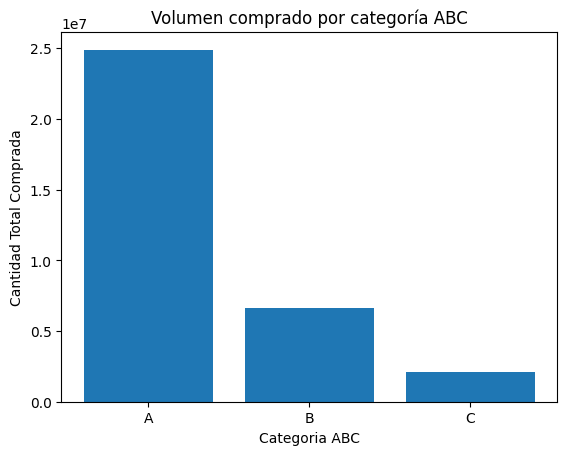

In [71]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(compras_abc["CategoriaABC"], compras_abc["Cantidad_Total_Comprada"])
plt.title("Volumen comprado por categoría ABC")
plt.xlabel("Categoria ABC")
plt.ylabel("Cantidad Total Comprada")
plt.show()

In [72]:
# Consumo anual por producto

consumo_prod = (
    balance
    .groupby("Brand")["Consumo"]
    .sum()
    .reset_index()
)

# Compras anuales por producto
compras_prod = (
    Compra_final
    .groupby("Brand")["Quantity"]
    .sum()
    .reset_index(name="Compras")
)

# Unimos
df_cc = compras_prod.merge(consumo_prod, on="Brand", how="inner")

# Limpiamos casos problemáticos (evitar división por 0 y consumos negativos)
df_cc = df_cc[df_cc["Consumo"] > 0].copy()

# Ratio compras/consumo
df_cc["Ratio_Compras_Consumo"] = df_cc["Compras"] / df_cc["Consumo"]

# Correlación Compras vs Consumo (si el consumo sube, ¿compras suben?)
corr = df_cc["Compras"].corr(df_cc["Consumo"])

print("Compras vs Consumo (por producto)")
print("Productos analizados:", df_cc["Brand"].nunique())
print("Correlación (Compras vs Consumo):", round(corr, 4))

print("Señales operativas (por ratio)")
print("Alineados (0.9 - 1.1):", ((df_cc["Ratio_Compras_Consumo"]>=0.9)&(df_cc["Ratio_Compras_Consumo"]<=1.1)).sum())
print("Sobrecompra (> 1.2):", (df_cc["Ratio_Compras_Consumo"]>1.2).sum())
print("Posible quiebre (< 0.8):", (df_cc["Ratio_Compras_Consumo"]<0.8).sum())

print("Top 10 sobrecompra (mayor ratio)")
print(df_cc.sort_values("Ratio_Compras_Consumo", ascending=False)
          .head()[["Brand","Compras","Consumo","Ratio_Compras_Consumo"]]
          .to_string(index=False))

print("Top 10 posible quiebre (menor ratio)")
print(df_cc.sort_values("Ratio_Compras_Consumo", ascending=True)
          .head()[["Brand","Compras","Consumo","Ratio_Compras_Consumo"]]
          .to_string(index=False))

Compras vs Consumo (por producto)
Productos analizados: 10486
Correlación (Compras vs Consumo): 0.9987
Señales operativas (por ratio)
Alineados (0.9 - 1.1): 4870
Sobrecompra (> 1.2): 2633
Posible quiebre (< 0.8): 1803
Top 10 sobrecompra (mayor ratio)
 Brand  Compras  Consumo  Ratio_Compras_Consumo
 27342     1065      3.0                  355.0
 15880      600      2.0                  300.0
 27553      228      1.0                  228.0
 27274      174      1.0                  174.0
 27969      168      1.0                  168.0
Top 10 posible quiebre (menor ratio)
 Brand  Compras  Consumo  Ratio_Compras_Consumo
  4703       10   2745.0               0.003643
 11209        1    171.0               0.005848
  5831        4    684.0               0.005848
  5335        1    159.0               0.006289
  3406        1    158.0               0.006329


## BLOQUE 7 – Análisis Financiero del Inventario
Objetivo: Traducir el estado operativo del inventario a una dimensión económica, cuantificando el capital inmovilizado y evaluando su eficiencia según rotación, clasificación ABC y distribución por sucursal, con el fin de identificar oportunidades de optimización del working capital.

In [78]:
# Costo representativo por Brand
cost_rep = (
    Compra_final
    .groupby("Brand", as_index=False)["PurchasePrice"]
    .median()
    .rename(columns={"PurchasePrice": "CostRep"})
)

print("CostRep listo:", cost_rep.shape)
cost_rep.head()

CostRep listo: (10664, 2)


,Brand,CostRep
0,58,9.28
1,60,7.40
2,61,10.60
3,62,28.67
4,63,30.46


In [79]:
# Stock final por tienda y producto
stock_final = (
    Final_inventario
    .groupby(["Store", "Brand"], as_index=False)["onHand"]
    .sum()
    .rename(columns={"onHand": "StockFinal"})
)

print("Stock final listo:", stock_final.shape)
stock_final.head()

Stock final listo: (224489, 3)


,Store,Brand,StockFinal
0,1,58,11
1,1,62,7
2,1,63,7
3,1,72,4
4,1,75,7


In [80]:
# Merge stock + costo
fin_base = stock_final.merge(cost_rep, on="Brand", how="left")

# Control productos sin costo
faltan_costos = fin_base["CostRep"].isna().sum()
if faltan_costos > 0:
    print(f"Filas sin costo (Brand sin compras): {faltan_costos} -> se excluirán del cálculo monetario")

# Capital inmovilizado
fin_base["CapitalInmovilizado"] = fin_base["StockFinal"] * fin_base["CostRep"]

# Solo datos valorizables
fin_cap = fin_base.dropna(subset=["CostRep"]).copy()

# KPIs generales
capital_total = fin_cap["CapitalInmovilizado"].sum()
unidades_total = fin_cap["StockFinal"].sum()
skus_valorizables = fin_cap["Brand"].nunique()

print("\nKPI GENERAL")
print(f"SKUs valorizables: {skus_valorizables:,}")
print(f"Unidades Stock Final: {unidades_total:,.0f}")
print(f"Working Capital (Inventario a costo): ${capital_total:,.2f}")

Filas sin costo (Brand sin compras): 1176 -> se excluirán del cálculo monetario

KPI GENERAL
SKUs valorizables: 9,289
Unidades Stock Final: 4,882,593
Working Capital (Inventario a costo): $55,293,243.91


In [81]:
# Validación ABC
req_abc = {"Brand", "CategoriaABC"}
if not req_abc.issubset(abc.columns):
    raise KeyError(f"Tu DF abc debe tener {req_abc}. Tiene: {set(abc.columns)}")

# Mapeo ABC
abc_map = abc[["Brand","CategoriaABC"]].drop_duplicates("Brand")

# Merge capital + ABC
fin_abc = fin_cap.merge(abc_map, on="Brand", how="left")

# Agregado
cap_abc = (
    fin_abc
    .groupby("CategoriaABC", as_index=False)
    .agg(
        Capital=("CapitalInmovilizado","sum"),
        Unidades=("StockFinal","sum"),
        SKUs=("Brand","nunique")
    )
    .sort_values("Capital", ascending=False)
)

cap_abc["ShareCapital"] = cap_abc["Capital"] / cap_abc["Capital"].sum()

print("\nCAPITAL POR ABC")
cap_abc


CAPITAL POR ABC


,CategoriaABC,Capital,Unidades,SKUs,ShareCapital
0,A,35296914.53,2967591,1543,0.638359
1,B,11420714.38,1217946,2034,0.206548
2,C,8575615.00,697056,5712,0.155093


In [82]:
# Validar rotación
req_rot = {"Brand","Rotacion"}
if not req_rot.issubset(rotacion.columns):
    raise KeyError(f"Tu tabla rotacion debe tener {req_rot}. Tiene: {set(rotacion.columns)}")

# Merge rotación
fin_rot = fin_cap.merge(rotacion[["Brand","Rotacion"]], on="Brand", how="left")
fin_rot = fin_rot.dropna(subset=["Rotacion"]).copy()

# Percentil 25
umbral_rot_p25 = fin_rot["Rotacion"].quantile(0.25)

fin_rot["EsBajaRotacion"] = fin_rot["Rotacion"] <= umbral_rot_p25

capital_lento = fin_rot.loc[fin_rot["EsBajaRotacion"],"CapitalInmovilizado"].sum()
share_lento = capital_lento / capital_total if capital_total else 0

print("\nCAPITAL LENTO")
print(f"Umbral baja rotación (p25): {umbral_rot_p25:.2f}")
print(f"Capital baja rotación: ${capital_lento:,.2f}")
print(f"Share sobre capital total: {share_lento:.2%}")


CAPITAL LENTO
Umbral baja rotación (p25): 3.00
Capital baja rotación: $17,205,540.44
Share sobre capital total: 31.12%


In [83]:
fin_rot_abc = fin_rot.merge(abc_map, on="Brand", how="left")

capital_lento_C = fin_rot_abc.loc[
    (fin_rot_abc["EsBajaRotacion"]) & (fin_rot_abc["CategoriaABC"]=="C"),
    "CapitalInmovilizado"
].sum()

share_lento_C = capital_lento_C / capital_total if capital_total else 0

print("Capital lento en C:", f"${capital_lento_C:,.2f}")
print("Share lento C / total:", f"{share_lento_C:.2%}")

Capital lento en C: $6,891,428.77
Share lento C / total: 12.46%


In [84]:
cap_store = (
    fin_cap
    .groupby("Store", as_index=False)
    .agg(
        Capital=("CapitalInmovilizado","sum"),
        Unidades=("StockFinal","sum"),
        SKUs=("Brand","nunique")
    )
    .sort_values("Capital", ascending=False)
)

cap_store["Share"] = cap_store["Capital"] / cap_store["Capital"].sum()
cap_store["ShareAcum"] = cap_store["Share"].cumsum()

tiendas_80 = int((cap_store["ShareAcum"] <= 0.80).sum())

print("\nTOP 10 SUCURSALES POR CAPITAL")
cap_store.head(10)


TOP 10 SUCURSALES POR CAPITAL


,Store,Capital,Unidades,SKUs,Share,ShareAcum
49,50,3452057.21,260704,7095,0.062432,0.062432
72,73,2225108.69,164402,5389,0.040242,0.102674
66,67,2125269.51,163470,5068,0.038436,0.141110
33,34,2102446.05,144948,6292,0.038024,0.179134
75,76,2046897.61,143689,5069,0.037019,0.216153
68,69,2025102.23,150233,5619,0.036625,0.252777
65,66,1983994.74,144433,4831,0.035881,0.288659
73,74,1966029.29,166015,5199,0.035556,0.324215
37,38,1678120.63,129324,4909,0.030349,0.354565
54,55,1528669.03,125409,4761,0.027647,0.382211


In [85]:
resumen_b7 = pd.DataFrame([{
    "CapitalTotal_WorkingCapital": capital_total,
    "UnidadesStockFinal": unidades_total,
    "SKUs_valorizables": skus_valorizables,
    "CapitalBajaRotacion": capital_lento,
    "ShareCapitalBajaRotacion": share_lento,
    "CapitalBajaRotacion_en_C": capital_lento_C,
    "ShareBajaRotacion_en_C": share_lento_C,
    "Tiendas_80pct_capital": tiendas_80,
    "TotalTiendas": int(cap_store.shape[0])
}])

print("\nRESUMEN BLOQUE 7")
resumen_b7


RESUMEN BLOQUE 7


,CapitalTotal_WorkingCapital,UnidadesStockFinal,SKUs_valorizables,CapitalBajaRotacion,ShareCapitalBajaRotacion,CapitalBajaRotacion_en_C,ShareBajaRotacion_en_C,Tiendas_80pct_capital,TotalTiendas
0,55293243.91,4882593,9289,17205540.44,0.311169,6891428.77,0.124634,41,80
